In [19]:
import calendar
from pathlib import Path

import cmocean.cm as cmo
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import distributions

In [20]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR
    / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR
    / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered.nc"

In [21]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH)

# resample midshelf nitrate to fill some of the gaps for composite calclulations
midshelf_nitrate = midshelf_nitrate.resample(time="1D").mean()

# interpolate velocity depths to match 1 meter bins in midshelf nitrate
velocity = velocity.interp(depth=midshelf_nitrate.depth)

## Nitrate and Wind Time Series

Text(0.02, 0.95, 'Downwelling\nFavorable')

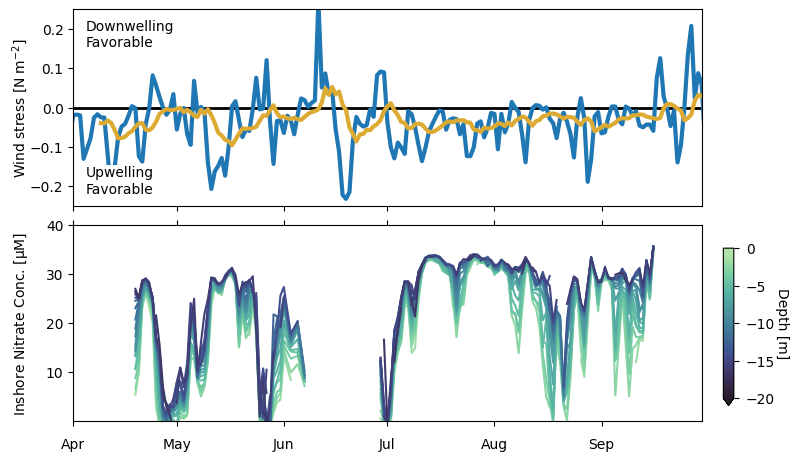

In [22]:
# single year time series
# plt.
fig, axs = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True, layout="constrained")
temp = wind.where(wind["time.year"] == 2021, drop=True)
(ln1,) = axs[0].plot(temp.time, temp.coare_y, label="Stress", lw=3, zorder=1.8)
(ln2,) = axs[0].plot(
    temp.time, temp.w5d, color="#DDAA33", label="$W_{5d}$", lw=3, zorder=1.8
)
axs[0].axhline(0, ls="-", lw=2, color="black", zorder=1.5)
axs[0].set_ylim(-0.25, 0.25)
# axs2.set_yticks([-50, 0, 100, 200])
# axs2.tick_params(axis='y', which='minor', left=False, top=False)
# axs[0].tick_params(axis='y', which='minor', left=False, top=False)
# fig.tight_layout(pad=0)

axs[0].set_xlim(np.datetime64("2021-04-01"), np.datetime64("2021-09-30"))
axs[0].tick_params(axis="x", which="minor", bottom=False, top=False)


# axs[0].set_zorder(1)  # default zorder is 0 for ax1 and ax2
# axs[0].patch.set_visible(False)  # prevents ax1 from hiding ax2

deployment = np.arange(15, 20, 1)
temp = inner_nitrate.where(inner_nitrate["time.year"] == 2021, drop=True)

cmap = cmo.tools.crop_by_percent(
    cmo.deep, 10, which="min", N=len(temp.depth.where(temp.depth < 21.5, drop=True))
)
cdict = cmo.tools.get_dict(cmap, N=len(temp.depth.where(temp.depth < 21.5, drop=True)))
deep = LinearSegmentedColormap("cmap", cdict)

for i, d in enumerate(temp.depth):
    for j, dep in enumerate(deployment):
        temp_dep = temp.where(temp.deployment == dep).where(temp.nitrate < 38)
        if (len(temp_dep.time) > 0) & (~np.all(np.isnan(temp.sel(depth=d).nitrate))):
            axs[1].plot(
                temp_dep.sel(depth=d).time,
                temp_dep.sel(depth=d).nitrate,
                color=deep((i + 1) / len(inner_nitrate.depth)),
                lw=1.5,
            )

axs[1].tick_params(axis="x", which="major", bottom=True, top=True, pad=8)
myFmt = mdates.DateFormatter("%b")
axs[1].xaxis.set_major_formatter(myFmt)
axs[0].set_ylabel("Wind stress [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)

# axs[1].set_xlim(temp.time[0], temp.time[-1])
axs[1].tick_params(axis="x", which="minor", bottom=False, top=False)
axs[1].set_ylim(0, 40)
axs[1].set_yticks([10, 20, 30, 40])
axs[1].set_ylabel("Inshore Nitrate Conc. [$\\mathsf{\\mu M}$]", labelpad=0)
fig.align_ylabels(axs)


# plt.tight_layout()
deep_r = cmo.tools.crop_by_percent(
    cmo.deep_r, 10, which="max", N=len(temp.depth.where(temp.depth < 21.5, drop=True))
)
cax = fig.add_axes(
    rect=(
        axs[1].get_position().x0 + 0.9,
        axs[1].get_position().y0,
        0.015,
        axs[1].get_position().height,
    )
)
scm = plt.cm.ScalarMappable(cmap=deep_r, norm=plt.Normalize(vmin=-20, vmax=0))
cbar = fig.colorbar(scm, cax=cax, ax=axs, fraction=0.01, extend="min")
cbar.ax.tick_params(labelsize=10, pad=5)
cbar.ax.minorticks_off()
# cbar.ax.get_yaxis().set_ticks([0, -5, -10, -15, -20])
# cbar.ax.get_yaxis().set_ticklabels([0, '', '10', '', '20'])
cbar.set_label("Depth [m]", labelpad=10, rotation=270)
# cbar.ax.tick_params(labelsize=40)

axs[0].text(
    0.02,
    0.05,
    "Upwelling\nFavorable",
    bbox=dict(facecolor="white", alpha=1, edgecolor="white", boxstyle="round,pad=0."),
    transform=axs[0].transAxes,
    va="bottom",
    ha="left",
    zorder=2,
)
axs[0].text(
    0.02,
    0.95,
    "Downwelling\nFavorable",
    bbox=dict(facecolor="white", alpha=1, edgecolor="white", boxstyle="round,pad=0."),
    transform=axs[0].transAxes,
    va="top",
    ha="left",
    zorder=2,
)


# if savefigs:
#     plt.savefig(
#         "../../figs/nitrate-wind_manuscript_figs/wind-nitrate_time_series_w8d.png",
#         dpi=600,
#     )

In [23]:
def plot_wind_velocity_nitrate_time_series(
    wind: xr.Dataset,
    velocity: xr.Dataset,
    inner_nitrate: xr.Dataset,
    midshelf_nitrate: xr.Dataset,
    year: int,
    save: bool = False,
) -> None:
    if save:
        plt.ioff()
    # single year time series
    fig, axs = plt.subplots(2, 2, figsize=(7, 4), sharex=True, layout="constrained")

    fig.align_ylabels(axs)
    axs[0, 0].plot(wind.time, wind.coare_y, "--", label="Stress", zorder=1.8)
    axs[0, 0].plot(
        wind.time, wind.w5d, color="#DDAA33", label=r"$\mathrm{W_{5d}}$", zorder=1.8
    )
    axs[0, 0].axhline(0, ls="-", lw=2, color="black", zorder=1.5)
    axs[0, 0].set_ylim(-0.25, 0.25)
    axs[0, 0].set_xlim(np.datetime64(f"{year}-04-01"), np.datetime64(f"{year}-09-30"))
    axs[0, 0].tick_params(axis="x", which="minor", bottom=False, top=False)
    axs[0, 0].text(
        0.02,
        0.05,
        "Upwelling\nFavorable",
        bbox=dict(
            facecolor="white", alpha=1, edgecolor="white", boxstyle="round,pad=0."
        ),
        transform=axs[0, 0].transAxes,
        va="bottom",
        ha="left",
        zorder=2,
    )
    axs[0, 0].text(
        0.02,
        0.95,
        "Downwelling\nFavorable",
        bbox=dict(
            facecolor="white", alpha=1, edgecolor="white", boxstyle="round,pad=0."
        ),
        transform=axs[0, 0].transAxes,
        va="top",
        ha="left",
        zorder=2,
    )
    axs[0, 0].set_ylabel("Along-shelf\nWind Stress [$\\mathsf{N\\;m^{-2}}$]")
    axs[0, 0].legend(
        ncols=2, loc="upper right", frameon=True, framealpha=1, columnspacing=1
    )

    axs[1, 0].axhline(0, zorder=1.5, color="k")
    axs[1, 0].plot(
        velocity.time,
        velocity.sel(depth=30).cs,
        "--",
        label="30 m",
        color="#BB5566",
    )
    axs[1, 0].plot(
        velocity.time,
        velocity.sel(depth=70).cs,
        label="70 m",
        color="#228833",
    )
    axs[1, 0].set_ylabel("Cross-shelf\nVelocity [$\\mathsf{m \\; s^{-1}}$]")
    axs[1, 0].legend(
        ncols=2, loc="upper right", frameon=True, framealpha=1, columnspacing=1
    )
    axs[1, 0].text(
        0.02,
        0.05,
        "Offshore",
        bbox=dict(
            facecolor="white", alpha=1, edgecolor="white", boxstyle="round,pad=0."
        ),
        transform=axs[1, 0].transAxes,
        va="bottom",
        ha="left",
        zorder=2,
    )
    axs[1, 0].text(
        0.02,
        0.95,
        "Onshore",
        bbox=dict(
            facecolor="white", alpha=1, edgecolor="white", boxstyle="round,pad=0."
        ),
        transform=axs[1, 0].transAxes,
        va="top",
        ha="left",
        zorder=2,
    )

    deployment = np.unique(inner_nitrate.deployment)
    deployment = deployment[~np.isnan(deployment)]
    cmap = cmo.tools.crop_by_percent(
        cmo.deep,
        10,
        which="min",
        N=len(inner_nitrate.depth.where(inner_nitrate.depth < 25, drop=True)),
    )
    cdict = cmo.tools.get_dict(
        cmap, N=len(inner_nitrate.depth.where(inner_nitrate.depth < 25, drop=True))
    )
    deep = LinearSegmentedColormap("cmap", cdict)
    for i, d in enumerate(inner_nitrate.depth):
        for j, dep in enumerate(deployment):
            temp = inner_nitrate.where(inner_nitrate.deployment == dep).where(
                inner_nitrate.nitrate < 38
            )
            axs[0, 1].plot(
                temp.sel(depth=d).time,
                temp.sel(depth=d).nitrate,
                color=deep((i + 1) / len(inner_nitrate.depth)),
                lw=1.5,
            )

    myFmt = mdates.DateFormatter("%b")
    axs[0, 1].xaxis.set_major_formatter(myFmt)
    axs[0, 1].set_ylim(0, 40)
    axs[0, 1].set_yticks([0, 10, 20, 30, 40])
    axs[0, 1].set_ylabel("Inshore Nitrate\nConc. [$\\mathsf{mmol \\; m^{-3}}$]")
    # fig.align_ylabels(axs)
    deep_r = cmo.tools.crop_by_percent(
        cmo.deep_r, 10, which="max", N=len(temp.depth.where(temp.depth < 25, drop=True))
    )
    cax = fig.add_axes(
        rect=(
            axs[0, 1].get_position().x0 + 0.475,
            axs[0, 1].get_position().y0 + 0.05,
            0.015,
            axs[0, 1].get_position().height,
        )
    )
    scm = plt.cm.ScalarMappable(cmap=deep_r, norm=plt.Normalize(vmin=-20, vmax=0))
    cbar = fig.colorbar(scm, cax=cax, fraction=0.01, extend="min")
    cbar.ax.tick_params(labelsize=10, pad=5)
    cbar.ax.minorticks_off()
    cbar.ax.get_yaxis().set_ticks([0, -5, -10, -15, -20])
    cbar.set_label("Depth [m]", labelpad=10, rotation=270)

    deployment = np.unique(midshelf_nitrate.deployment)
    deployment = deployment[~np.isnan(deployment)]
    cmap = cmo.tools.crop_by_percent(
        cmo.deep,
        10,
        which="min",
        N=len(midshelf_nitrate.depth.where(midshelf_nitrate.depth < 80, drop=True)),
    )
    cdict = cmo.tools.get_dict(
        cmap,
        N=len(midshelf_nitrate.depth.where(midshelf_nitrate.depth < 80, drop=True)),
    )
    deep = LinearSegmentedColormap("cmap", cdict)
    for i, d in enumerate(midshelf_nitrate.depth):
        for j, dep in enumerate(deployment):
            temp = midshelf_nitrate.where(cond=midshelf_nitrate.deployment == dep)
            if (len(temp_dep.time) > 0) & (
                ~np.all(np.isnan(temp.sel(depth=d).nitrate))
            ):
                axs[1, 1].plot(
                    temp.sel(depth=d).time,
                    temp.sel(depth=d).nitrate,
                    color=deep((i + 1) / len(midshelf_nitrate.depth)),
                    lw=1.5,
                )
    myFmt = mdates.DateFormatter("%b")
    axs[1, 1].xaxis.set_major_formatter(myFmt)
    axs[1, 1].set_ylim(0, 40)
    axs[1, 1].set_yticks([0, 10, 20, 30, 40])
    axs[1, 1].set_ylabel("Midshelf Nitrate\nConc. [$\\mathsf{mmol \\; m^{-3}}$]")
    deep_r = cmo.tools.crop_by_percent(
        cmo.deep_r, 10, which="max", N=len(temp.depth.where(temp.depth < 80, drop=True))
    )
    cax = fig.add_axes(
        rect=(
            axs[1, 1].get_position().x0 + 0.475,
            axs[1, 1].get_position().y0,
            0.015,
            axs[1, 1].get_position().height,
        )
    )
    scm = plt.cm.ScalarMappable(cmap=deep_r, norm=plt.Normalize(vmin=-80, vmax=0))
    cbar = fig.colorbar(scm, cax=cax, fraction=0.01, extend="min")
    cbar.ax.tick_params(labelsize=10, pad=5)
    cbar.ax.minorticks_off()
    cbar.ax.get_yaxis().set_ticks([0, -20, -40, -60, -80])
    cbar.set_label("Depth [m]", labelpad=10, rotation=270)

    axs[0, 0].annotate("(a)", xy=(0.9, 0.05), xycoords="axes fraction", fontsize=10)
    axs[0, 1].annotate("(b)", xy=(0.9, 0.05), xycoords="axes fraction", fontsize=10)
    axs[1, 0].annotate("(c)", xy=(0.9, 0.05), xycoords="axes fraction", fontsize=10)
    axs[1, 1].annotate("(d)", xy=(0.9, 0.05), xycoords="axes fraction", fontsize=10)
    axs[0, 0].minorticks_off()
    axs[0, 1].minorticks_off()
    axs[1, 0].minorticks_off()
    axs[1, 1].minorticks_off()

    if save:
        plt.savefig(
            FIGURES_DIR / f"manuscript/si/wind-nitrate-time-series-{year}.pdf",
            format="pdf",
            bbox_inches="tight",
        )
    if not save:
        plt.show()
    plt.ion()
    plt.close()

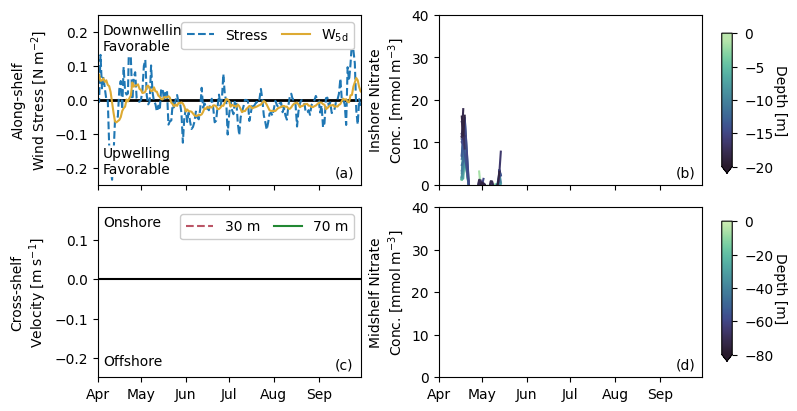

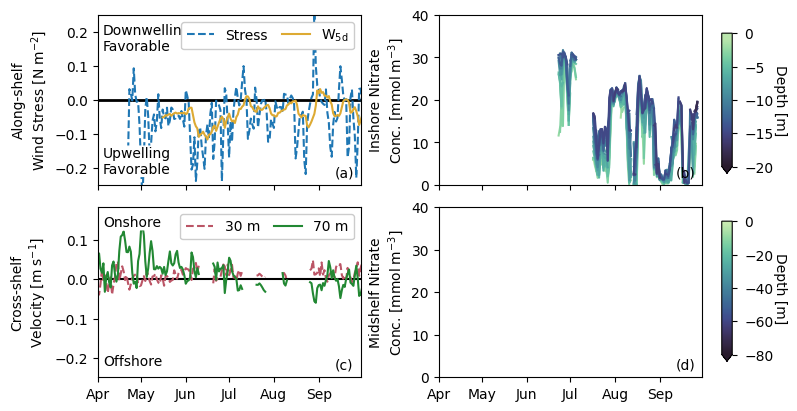

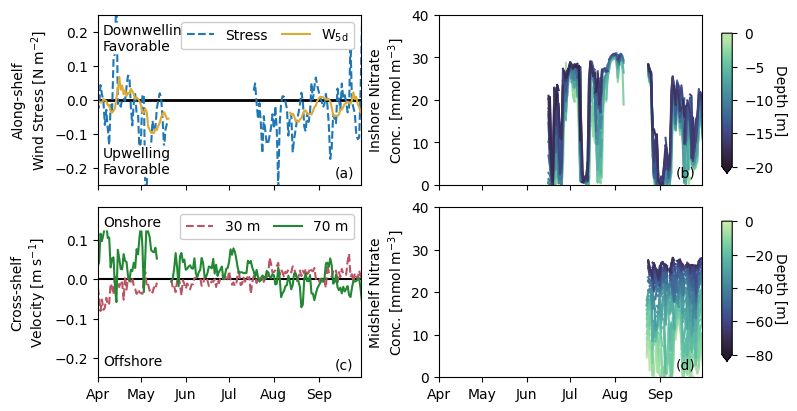

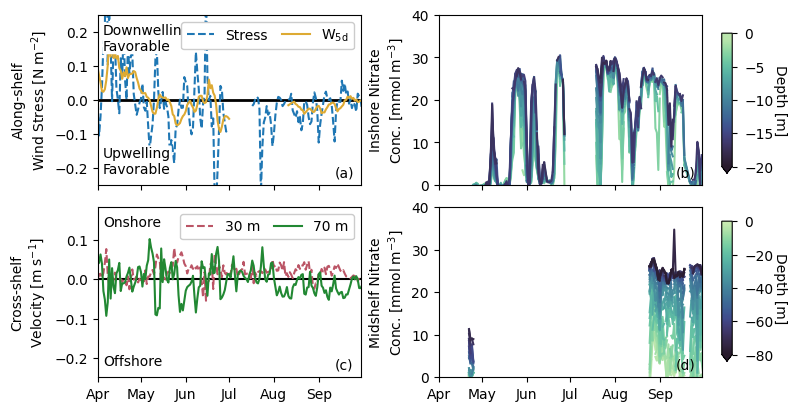

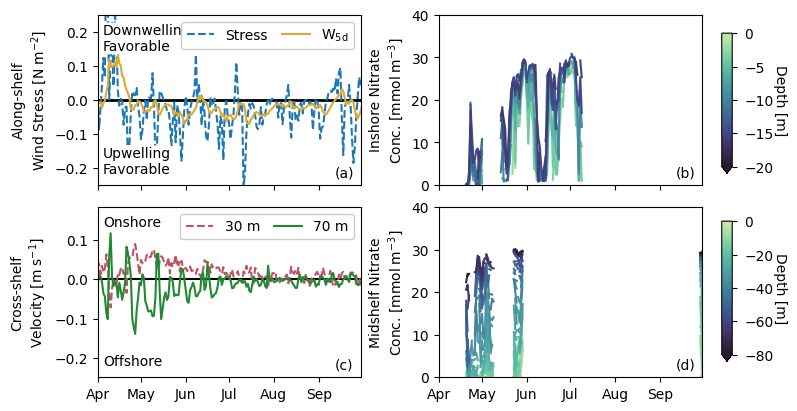

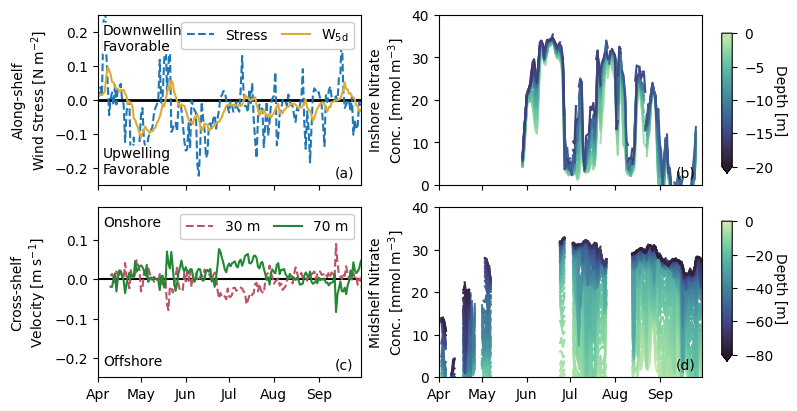

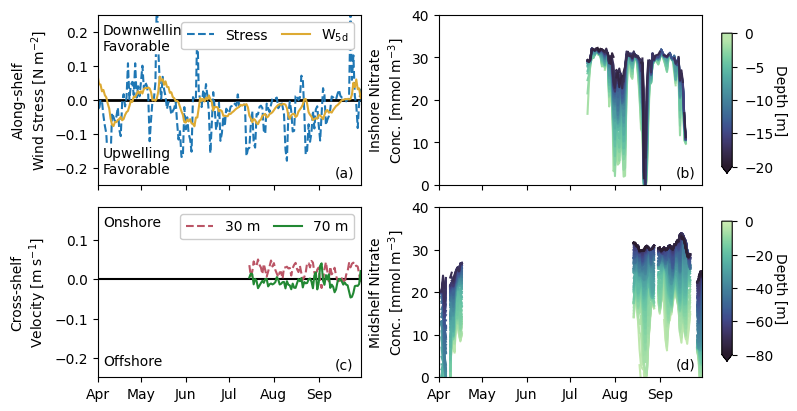

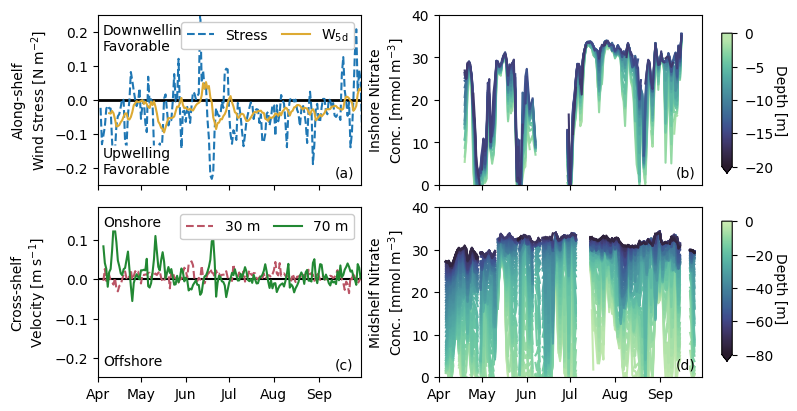

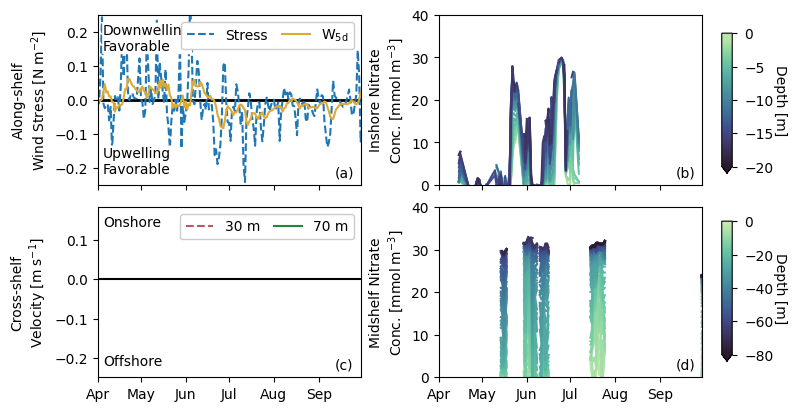

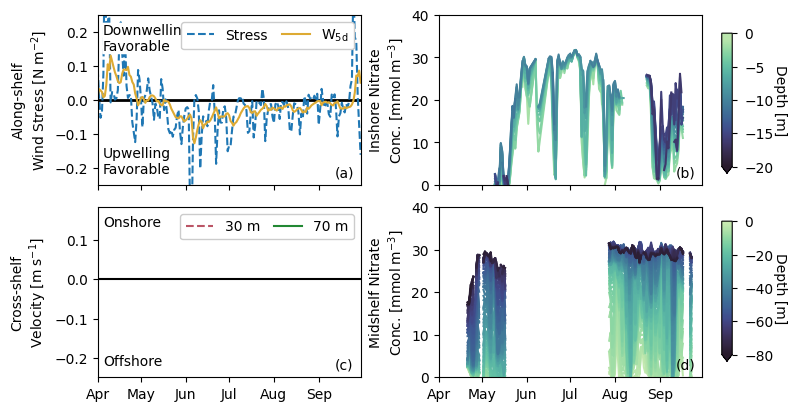

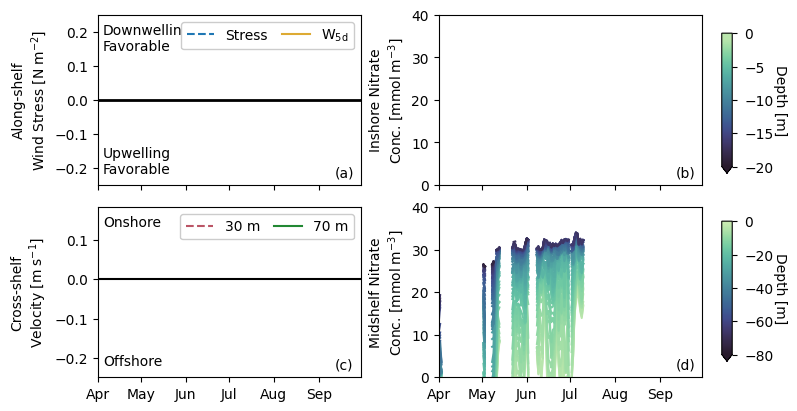

In [24]:
for i in range(2014, 2025):
    plot_wind_velocity_nitrate_time_series(
        wind, velocity, inner_nitrate, midshelf_nitrate, i, save=False
    )

Text(0, 0.5, 'Depth-Averaged Nitrate Conc. [$\\mathsf{mmol \\; m^{-3}}$]')

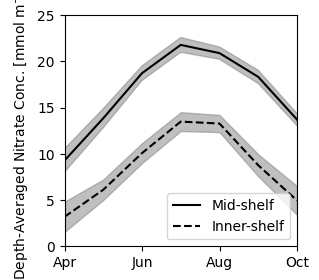

In [25]:
midshelf_depth_integrate = midshelf_nitrate.copy()
fig, axs = plt.subplots(1, 1, figsize=(3, 3), sharex=True)
axs.plot(
    midshelf_depth_integrate["depth_integrated_nitrate"]
    .groupby("time.month")
    .mean(dim="time")
    .month,
    midshelf_depth_integrate["depth_integrated_nitrate"]
    .groupby("time.month")
    .mean(dim="time")
    / 80,
    color="black",
    label="Mid-shelf",
)
axs.fill_between(
    midshelf_depth_integrate["depth_integrated_nitrate"]
    .groupby("time.month")
    .mean(dim="time")
    .month,
    midshelf_depth_integrate["depth_integrated_nitrate"]
    .groupby("time.month")
    .mean(dim="time")
    / 80
    - (
        midshelf_depth_integrate["depth_integrated_nitrate"]
        .groupby("time.month")
        .std(dim="time")
        / np.sqrt(
            midshelf_depth_integrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
        )
        * distributions.t(
            midshelf_depth_integrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
            - 1
        ).isf(0.025)
    )
    / 80,
    midshelf_depth_integrate["depth_integrated_nitrate"]
    .groupby("time.month")
    .mean(dim="time")
    / 80
    + (
        midshelf_depth_integrate["depth_integrated_nitrate"]
        .groupby("time.month")
        .std(dim="time")
        / np.sqrt(
            midshelf_depth_integrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
        )
        * distributions.t(
            midshelf_depth_integrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
            - 1
        ).isf(0.025)
    )
    / 80,
    alpha=0.5,
    color="gray",
)

axs.plot(
    inner_nitrate["depth_integrated_nitrate"]
    .groupby("time.month")
    .mean(dim="time")
    .month,
    inner_nitrate["depth_integrated_nitrate"].groupby("time.month").mean(dim="time")
    / 25,
    color="black",
    ls="--",
    label="Inner-shelf",
)
axs.fill_between(
    inner_nitrate["depth_integrated_nitrate"]
    .groupby("time.month")
    .mean(dim="time")
    .month,
    inner_nitrate["depth_integrated_nitrate"].groupby("time.month").mean(dim="time")
    / 25
    - (
        inner_nitrate["depth_integrated_nitrate"].groupby("time.month").std(dim="time")
        / np.sqrt(
            inner_nitrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
        )
        * distributions.t(
            inner_nitrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
            - 1
        ).isf(0.025)
    )
    / 25,
    inner_nitrate["depth_integrated_nitrate"].groupby("time.month").mean(dim="time")
    / 25
    + (
        inner_nitrate["depth_integrated_nitrate"].groupby("time.month").std(dim="time")
        / np.sqrt(
            inner_nitrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
        )
        * distributions.t(
            inner_nitrate["depth_integrated_nitrate"]
            .groupby("time.month")
            .count("time")
            - 1
        ).isf(0.025)
    )
    / 25,
    alpha=0.5,
    color="gray",
)

axs.set_xlim(4, 10)
axs.set_ylim(0, 25)
axs.minorticks_off()
axs.legend(loc="lower right")
# axs.xaxis.set_major_locator(mdates.MonthLocator())
axs.xaxis.set_major_formatter(lambda x, pos: calendar.month_abbr[int(x)])
# axs.set_xlabel('Month')
axs.set_ylabel("Depth-Averaged Nitrate Conc. [$\\mathsf{mmol \\; m^{-3}}$]")
# plt.savefig(
#     os.path.join(notebook_dir, "../manuscript/nitrate-seasonal-cycle.pdf"),
#     format="pdf",
#     bbox_inches="tight",
# )